# Sparse Table OCR — Net Income Analysis

This notebook reads the sparse income statement PDF, sends it through the Mistral OCR API, prints the markdown output, and reconstructs the net-income row while keeping empty cells as missing values.

The goal is to preserve the blank Q4 slot instead of letting later values shift left.

In [26]:
import importlib
import os

import ocr4_utils
from IPython.display import Markdown
import pandas as pd

ocr4_utils = importlib.reload(ocr4_utils)
from ocr4_utils import extract_pdf_lines, ocr_request

PDF_PATH = os.path.join(
    os.path.dirname(os.path.abspath('__file__')),
    'samples',
    'sparse_income_statement_with_net_income.pdf',
)

print(f'PDF path : {PDF_PATH}')
print(f'PDF size : {os.path.getsize(PDF_PATH):,} bytes')

PDF path : /Users/peymanmohajerian/Documents/tech/microsoft/cook-book/microsoft/ocr4-doc-ai/samples/sparse_income_statement_with_net_income.pdf
PDF size : 2,763 bytes


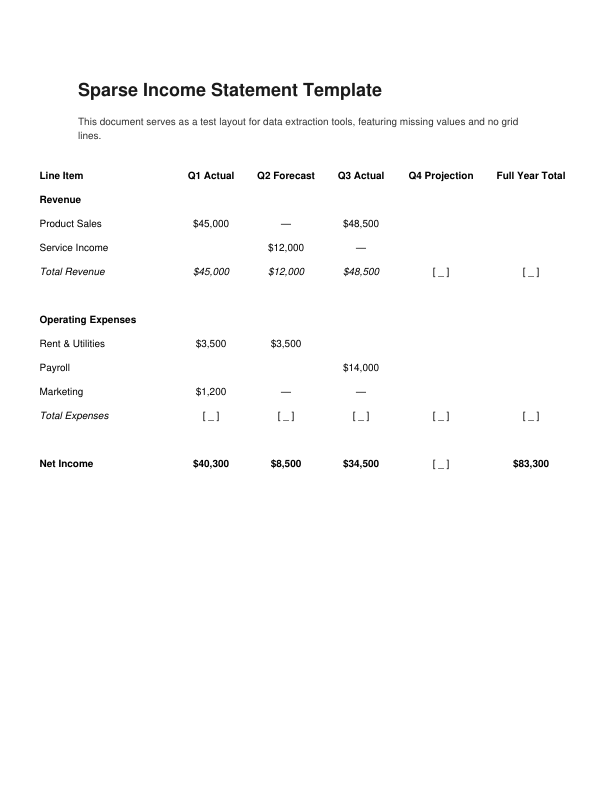

In [27]:
import fitz  # PyMuPDF
from IPython.display import Image, display

# Open the PDF document
doc = fitz.open(PDF_PATH)

# Load the first page (0-indexed)
page = doc.load_page(0)

# Render the page to a PNG image byte array
pix = page.get_pixmap()
image_bytes = pix.tobytes("png")

# Display the image inside VS Code
display(Image(data=image_bytes))

In [28]:
from ocr4_utils import build_ocr_payload

payload = build_ocr_payload(
    PDF_PATH,
    include_blocks=True,
    confidence_granularity='page',
    extract_header=True,
    extract_footer=True,
    table_format='markdown',
)
response = ocr_request(payload)
pages = response.get('pages', [])
print(f'Pages processed: {len(pages)}')

all_tables = [
    (table.get('content') or '').strip()
    for page in pages
    for table in page.get('tables', [])
    if (table.get('content') or '').strip()
]
print(f'Tables found in OCR payload: {len(all_tables)}')
for index, table in enumerate(all_tables[:3], start=1):
    print(f'\n--- table {index} snippet ---')
    print(table[:2000])

pdf_lines = extract_pdf_lines(PDF_PATH)
print('\n--- PDF text fallback ---')
for line in pdf_lines:
    print(line)

Pages processed: 1
Tables found in OCR payload: 1

--- table 1 snippet ---
|  Line Item | Q1 Actual | Q2 Forecast | Q3 Actual | Q4 Projection | Full Year Total  |
| --- | --- | --- | --- | --- | --- |
|  **Revenue**  |   |   |   |   |   |
|  Product Sales | $45,000 | — | $48,500 |  |   |
|  Service Income |  | $12,000 | — |  |   |
|  *Total Revenue* | *$45,000* | *$12,000* | *$48,500* | *[ _ ]* | *[ _ ]*  |
|  **Operating Expenses**  |   |   |   |   |   |
|  Rent & Utilities | $3,500 | $3,500 |  |  |   |
|  Payroll |  |  | $14,000 |  |   |
|  Marketing | $1,200 | — | — |  |   |
|  *Total Expenses* | *[ _ ]* | *[ _ ]* | *[ _ ]* | *[ _ ]* | *[ _ ]*  |
|  **Net Income** | **$40,300** | **$8,500** | **$34,500** | **[ _ ]** | **$83,300**  |

--- PDF text fallback ---
Sparse Income Statement Template
This document serves as a test layout for data extraction tools, featuring missing values and no grid
lines.
Line Item
Q1 Actual
Q2 Forecast
Q3 Actual
Q4 Projection
Full Year Total
Revenue
Produ

In [29]:
page0 = pages[0] if pages else {}
markdown_text = page0.get('markdown', '')
print(markdown_text[:4000])

# Sparse Income Statement Template

This document serves as a test layout for data extraction tools, featuring missing values and no grid lines.

[tbl-0.md](tbl-0.md)


## Sparse-table parsing strategy

When a table has empty cells, the usual failure mode is that later values shift left. The safe approach is to:

1. Read the raw OCR table content.
2. Split markdown rows.
3. Pad shorter rows to the header width.
4. Preserve empty cells as missing values.
5. Fall back to the source PDF text when OCR is ambiguous or sparse.

In [30]:
from ocr4_utils import (
    extract_net_income_values_from_pdf,
    markdown_table_to_df,
)

parsed_tables = [
    markdown_table_to_df(table_markdown)
    for table_markdown in all_tables
]
parsed_tables = [table for table in parsed_tables if not table.empty]

print(f'Parsed OCR tables: {len(parsed_tables)}')
for index, table in enumerate(parsed_tables[:3], start=1):
    print(f'\n--- parsed table {index} ---')
    display(table.head(10))

net_income_row = extract_net_income_values_from_pdf(pdf_lines)
print('\n--- net income row extracted from PDF text ---')
print(net_income_row)

Parsed OCR tables: 1

--- parsed table 1 ---


,Line Item,Q1 Actual,Q2 Forecast,Q3 Actual,Q4 Projection,Full Year Total
0,**Revenue**,<NA>,<NA>,<NA>,<NA>,<NA>
1,Product Sales,"$45,000",—,"$48,500",<NA>,<NA>
2,Service Income,<NA>,"$12,000",—,<NA>,<NA>
3,*Total Revenue*,"*$45,000*","*$12,000*","*$48,500*",*[ _ ]*,*[ _ ]*
4,**Operating Expenses**,<NA>,<NA>,<NA>,<NA>,<NA>
5,Rent & Utilities,"$3,500","$3,500",<NA>,<NA>,<NA>
6,Payroll,<NA>,<NA>,"$14,000",<NA>,<NA>
7,Marketing,"$1,200",—,—,<NA>,<NA>
8,*Total Expenses*,*[ _ ]*,*[ _ ]*,*[ _ ]*,*[ _ ]*,*[ _ ]*
9,**Net Income**,"**$40,300**","**$8,500**","**$34,500**",**[ _ ]**,"**$83,300**"



--- net income row extracted from PDF text ---
{'Q1 Actual': 40300.0, 'Q2 Forecast': 8500.0, 'Q3 Actual': 34500.0, 'Q4 Projection': None, 'Full Year Total': 83300.0}


In [31]:
# Rebuild the sparse row in a stable DataFrame while keeping the blank Q4 cell intact.
reconstructed_row = pd.DataFrame([
    {
        'Line Item': 'Net Income',
        'Q1 Actual': net_income_row.get('Q1 Actual'),
        'Q2 Forecast': net_income_row.get('Q2 Forecast'),
        'Q3 Actual': net_income_row.get('Q3 Actual'),
        'Q4 Projection': net_income_row.get('Q4 Projection'),
        'Full Year Total': net_income_row.get('Full Year Total'),
    }
])

print('Reconstructed sparse row:')
display(reconstructed_row)

numeric_values = [
    float(v) for v in [
        net_income_row.get('Q1 Actual'),
        net_income_row.get('Q2 Forecast'),
        net_income_row.get('Q3 Actual'),
        net_income_row.get('Full Year Total'),
    ] if pd.notna(v)
]
print(f'Observed numeric values: {numeric_values}')
print(f'Total income across the row: ${sum(numeric_values):,.2f}')

Reconstructed sparse row:


,Line Item,Q1 Actual,Q2 Forecast,Q3 Actual,Q4 Projection,Full Year Total
0,Net Income,40300.0,8500.0,34500.0,None,83300.0


Observed numeric values: [40300.0, 8500.0, 34500.0, 83300.0]
Total income across the row: $166,600.00


In [32]:
# Final human-readable summary.
q1 = net_income_row.get('Q1 Actual')
q2 = net_income_row.get('Q2 Forecast')
q3 = net_income_row.get('Q3 Actual')
q4 = net_income_row.get('Q4 Projection')
full_total = net_income_row.get('Full Year Total')

display(Markdown(
    "### Net income per quarter and total income\n\n"
    f"- Q1 Actual: **${float(q1):,.2f}**\n"
    f"- Q2 Forecast: **${float(q2):,.2f}**\n"
    f"- Q3 Actual: **${float(q3):,.2f}**\n"
    f"- Q4 Projection: **blank / missing**\n"
    f"- Full Year Total: **${float(full_total):,.2f}**"
))

### Net income per quarter and total income

- Q1 Actual: **$40,300.00**
- Q2 Forecast: **$8,500.00**
- Q3 Actual: **$34,500.00**
- Q4 Projection: **blank / missing**
- Full Year Total: **$83,300.00**

## Interpretation

For this sparse income statement, the source PDF clearly shows:

- Q1 Actual = $40,300
- Q2 Forecast = $8,500
- Q3 Actual = $34,500
- Q4 Projection = blank / missing
- Full Year Total = $83,300

The blank Q4 cell is preserved as missing rather than shifted left, which keeps the table aligned correctly and prevents the rest of the row from being corrupted.